# Regime-Aware GBM — WTI Weekly Return Forecasting
## 4-State Oil Market Regime Detection

Extends the walk-forward GBM by detecting the dominant market regime each week
and feeding regime probabilities as extra features.

**Regimes:**
| Regime | Driver signals |
|--------|---------------|
| `supply`   | OPEC event day, disruption intensity, OPEC sentiment |
| `demand`   | S&P 500 return, EIA inventory draw/build |
| `macro`    | USD momentum, 10Y yield change |
| `risk_off` | Realised vol, FinBERT negative prob, negative news ratio |

**Key insight:** The GBM can learn to up-weight OPEC features in `supply` regimes
and ignore CS_DI in `risk_off` regimes where stale sentiment hurts.


## 1. Imports & Config

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), ""))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.features.oil_regime import OilRegimeDetector

np.random.seed(42)

# ── Walk-forward parameters ────────────────────────────────────────────────────
INITIAL_TRAIN_WEEKS  = 104
STEP_WEEKS           = 13
CONFIDENCE_THRESHOLD = 1.0

# ── Model ──────────────────────────────────────────────────────────────────────
VOL_WINDOW = 8
DECAY_RATE = 0.995

BASE_FEATURE_COLS = [
    # News
    'headline_count_lag1', 'sentiment_mean_lag1', 'sentiment_std_lag1',
    'sentiment_min_lag1', 'sentiment_max_lag1',
    'negative_ratio_lag1', 'positive_ratio_lag1', 'log_headline_count_lag1',
    'opec_event_day_lag1', 'opec_decision_day_lag1', 'opec_sentiment_lag1',
    'disruption_event_day_lag1', 'disruption_intensity_lag1',
    # FinBERT
    'finbert_positive_mean_lag1', 'finbert_negative_mean_lag1', 'finbert_neutral_mean_lag1',
    # Regime (vol-based)
    'realized_vol_lag1',
    'regime_0_lag1', 'regime_1_lag1', 'regime_2_lag1',
    'hmm_regime_0_lag1', 'hmm_regime_1_lag1', 'hmm_regime_2_lag1',
    # EIA macro
    'inventory_chg_kb_lag1', 'inventory_surprise_kb_lag1',
    'production_chg_kbd_lag1', 'imports_chg_kbd_lag1',
    'refinery_util_pct_lag1', 'refinery_util_chg_pct_lag1',
    # FRED macro
    'usd_ret_pct_lag1', 'usd_mom_4w_lag1', 'spx_ret_pct_lag1', 'yield_10y_chg_lag1',
    # Paper features
    'broad_cs_di_lag1', 'opec_cs_di_lag1', 'disruption_cs_di_lag1',
    'broad_csi_v_lag1', 'opec_csi_v_lag1', 'disruption_csi_v_lag1',
]

# Regime prob cols are appended dynamically in the walk-forward loop
REGIME_PROB_COLS = [
    'regime_prob_supply', 'regime_prob_demand',
    'regime_prob_macro',  'regime_prob_risk_off',
]

TARGET_COL = 'close_pct_change'
print(f'Base features: {len(BASE_FEATURE_COLS)}  +  Regime probs: {len(REGIME_PROB_COLS)}  =  {len(BASE_FEATURE_COLS)+len(REGIME_PROB_COLS)} total')


Base features: 39  +  Regime probs: 4  =  43 total


## 2. Load Data

In [2]:
df = pd.read_parquet('../data/features/feature_matrix.parquet')
df = df.sort_values('date').reset_index(drop=True)

print(f'Rows: {len(df)}  |  Date range: {df["date"].min().date()} → {df["date"].max().date()}')
missing = [c for c in BASE_FEATURE_COLS if c not in df.columns]
print(f'Missing base features: {missing}' if missing else 'All base features present ✓')

# Pre-compute base feature matrix + targets (regime probs added per fold)
X_base      = df[BASE_FEATURE_COLS].fillna(0).values.astype(np.float32)
target_raw  = df[TARGET_COL].values.astype(np.float32)
rolling_vol = (df[TARGET_COL].rolling(VOL_WINDOW, min_periods=4).std()
               .clip(lower=0.5).bfill().values.astype(np.float32))
y           = np.clip(target_raw / rolling_vol, -10, 10)
dates       = df['date'].values
vols        = rolling_vol

n_folds = (len(df) - INITIAL_TRAIN_WEEKS) // STEP_WEEKS
print(f'First OOS date  : {pd.Timestamp(dates[INITIAL_TRAIN_WEEKS]).date()}')
print(f'Expected folds  : ~{n_folds}')


Rows: 369  |  Date range: 2019-02-08 → 2026-03-06
All base features present ✓
First OOS date  : 2021-02-12
Expected folds  : ~20


## 3. Regime Diagnostics
Fit the regime detector once on the pre-2023 training history to inspect
regime characteristics before the full walk-forward evaluation.


In [3]:
df_diag = df.iloc[:INITIAL_TRAIN_WEEKS]
det_diag = OilRegimeDetector()
det_diag.fit(df_diag)

print('Transition matrix (probability of staying / switching regime):')
print(det_diag.transition_matrix())
print()
print(f'Regime counts: {dict(det_diag.regime_counts(df_diag))}')
print()
print('Mean driver values per regime:')
print(det_diag.regime_summary(df_diag).T.round(3))


Transition matrix (probability of staying / switching regime):
          demand  supply  macro  risk_off
demand     0.471   0.529   0.00     0.000
supply     0.353   0.627   0.02     0.000
macro      0.000   0.000   0.90     0.100
risk_off   0.125   0.000   0.00     0.875

Regime counts: {'supply': np.int64(51), 'demand': np.int64(35), 'macro': np.int64(10), 'risk_off': np.int64(8)}

Mean driver values per regime:
regime                       demand     macro  risk_off    supply
opec_event_day_lag1           0.943     1.000     0.750     0.980
disruption_event_day_lag1     0.000     0.700     0.375     1.000
disruption_intensity_lag1     0.000     2.200     0.875     1.765
opec_sentiment_lag1           0.150    -0.274     0.015     0.225
inventory_chg_kb_lag1      -956.114  8589.800  3836.875 -1107.000
spx_ret_pct_lag1              0.742    -1.390     1.154     0.318
usd_ret_pct_lag1             -0.102     0.662    -0.398    -0.014
usd_mom_4w_lag1              -0.425     2.516    -1.41

Model is not converging.  Current: -3131.133202308624 is not greater than -3131.1307368212824. Delta is -0.0024654873413965106


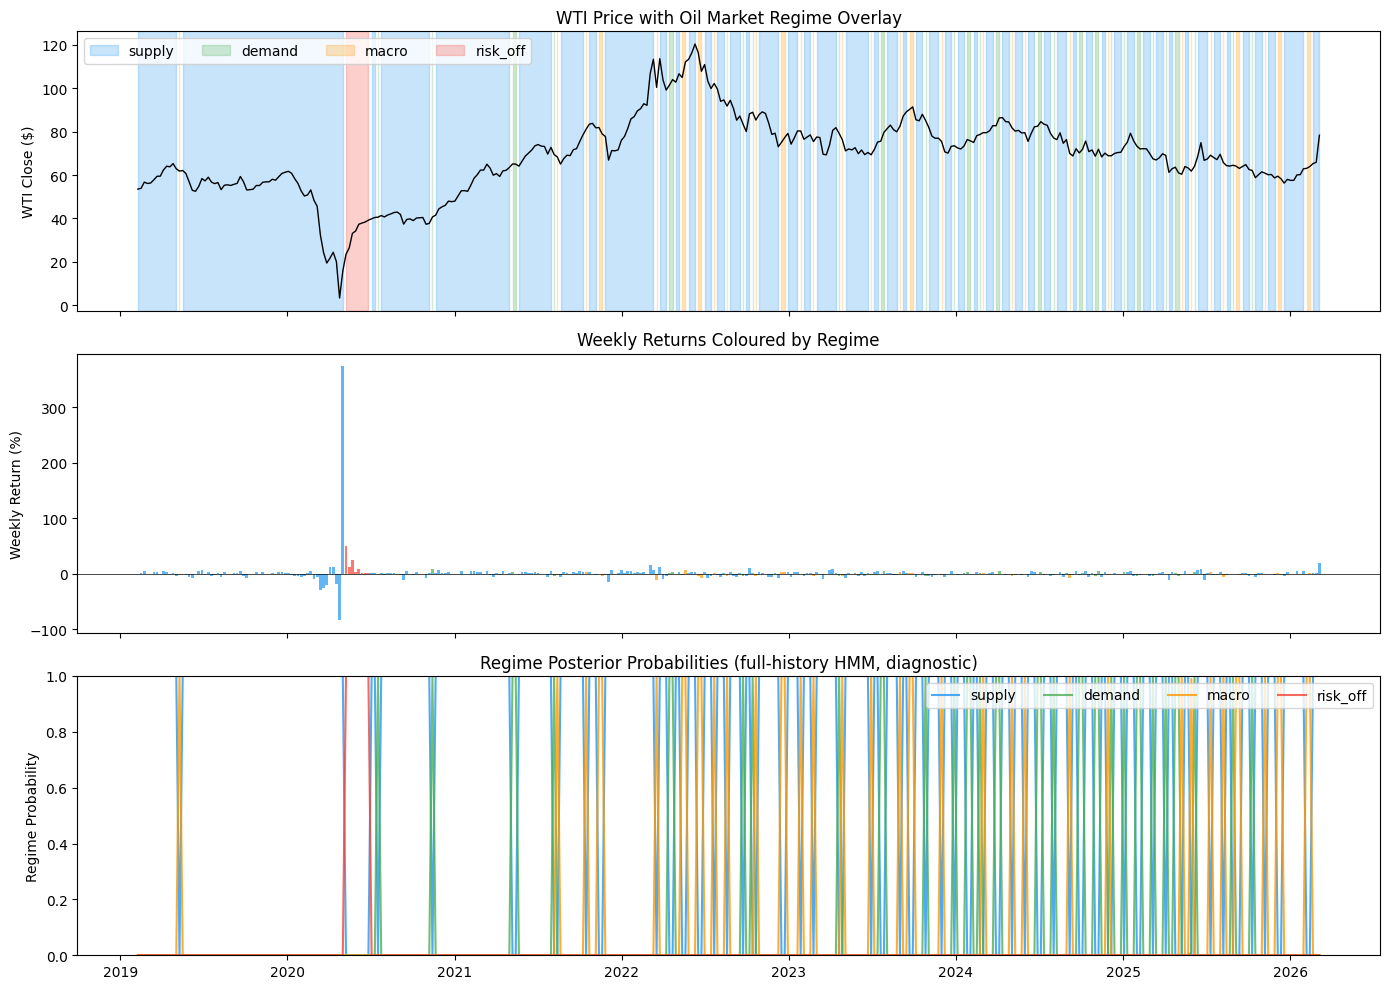


Regime distribution (full-history):
supply      285
macro        39
demand       37
risk_off      8


In [4]:
# Fit on full dataset for a full-history regime visualisation (diagnostic only)
det_full = OilRegimeDetector()
det_full.fit(df)
regime_labels = det_full.predict(df)
regime_proba  = det_full.predict_proba(df)
dates_ts = pd.to_datetime(df['date'])

REGIME_COLORS = {
    'supply':   '#2196F3',   # blue
    'demand':   '#4CAF50',   # green
    'macro':    '#FF9800',   # orange
    'risk_off': '#F44336',   # red
}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: WTI price coloured by regime
for regime, color in REGIME_COLORS.items():
    mask = regime_labels == regime
    axes[0].fill_between(dates_ts, 0, 1, where=mask,
                         transform=axes[0].get_xaxis_transform(),
                         alpha=0.25, color=color, label=regime)
axes[0].plot(dates_ts, df['close'], color='black', linewidth=1)
axes[0].set_ylabel('WTI Close ($)')
axes[0].set_title('WTI Price with Oil Market Regime Overlay')
axes[0].legend(loc='upper left', ncol=4)

# Panel 2: WTI weekly return
axes[1].bar(dates_ts, df['close_pct_change'], color=[REGIME_COLORS.get(r, 'grey') for r in regime_labels],
            width=6, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Weekly Return (%)')
axes[1].set_title('Weekly Returns Coloured by Regime')

# Panel 3: Regime probability stack
for regime, color in REGIME_COLORS.items():
    col = f'regime_prob_{regime}'
    if col in regime_proba.columns:
        axes[2].plot(dates_ts, regime_proba[col], color=color, label=regime, alpha=0.8)
axes[2].set_ylabel('Regime Probability')
axes[2].set_title('Regime Posterior Probabilities (full-history HMM, diagnostic)')
axes[2].legend(loc='upper right', ncol=4)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Regime distribution
counts = pd.Series(regime_labels).value_counts()
print('\nRegime distribution (full-history):')
print(counts.to_string())


## 4. Walk-Forward Training — Regime-Aware GBM

Each fold:
1. Fit `OilRegimeDetector` on training data only (no look-ahead)
2. Compute regime probabilities for train + test windows
3. Concatenate with base features → 43-feature input matrix
4. Train `HistGradientBoostingRegressor` with exponential sample weights
5. Evaluate OOS predictions


In [5]:
fold_records = []
all_preds    = []
last_model   = None
last_detector = None

for fold, test_start in enumerate(range(INITIAL_TRAIN_WEEKS, len(df), STEP_WEEKS)):
    test_end = min(test_start + STEP_WEEKS, len(df))
    if test_end - test_start < 5:
        break

    df_tr = df.iloc[:test_start]
    df_te = df.iloc[test_start:test_end]

    # ── Regime detection (training data only) ─────────────────────────────────
    detector = OilRegimeDetector()
    detector.fit(df_tr)

    proba_tr = detector.predict_proba(df_tr).values.astype(np.float32)
    proba_te = detector.predict_proba(df_te).values.astype(np.float32)
    regimes_te = detector.predict(df_te)

    # ── Augmented feature matrices (base + regime probs) ──────────────────────
    X_tr = np.hstack([X_base[:test_start],       proba_tr])
    X_te = np.hstack([X_base[test_start:test_end], proba_te])

    y_tr     = y[:test_start]
    act_raw  = target_raw[test_start:test_end]
    vols_te  = vols[test_start:test_end]
    dates_te = dates[test_start:test_end]

    # ── Exponential sample weights ────────────────────────────────────────────
    n     = len(X_tr)
    raw_w = np.array([DECAY_RATE ** (n - 1 - i) for i in range(n)], dtype=np.float32)
    sw    = raw_w / raw_w.mean()

    model_fold = HistGradientBoostingRegressor(
        max_iter=1000, learning_rate=0.02, max_depth=3,
        l2_regularization=2.0, loss='absolute_error',
        early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=30, random_state=42,
    )
    model_fold.fit(X_tr, y_tr, sample_weight=sw)

    preds_pct = model_fold.predict(X_te) * vols_te
    dir_acc_f = float(np.mean(np.sign(preds_pct) == np.sign(act_raw)))
    mae_f     = float(mean_absolute_error(act_raw, preds_pct))

    fold_records.append({
        'fold': fold, 'train_weeks': n,
        'test_start': pd.Timestamp(dates_te[0]).date(),
        'test_end':   pd.Timestamp(dates_te[-1]).date(),
        'n_test': len(act_raw), 'mae': mae_f, 'dir_acc': dir_acc_f,
        'iterations': model_fold.n_iter_,
    })

    for i in range(len(act_raw)):
        all_preds.append({
            'fold': fold, 'date': pd.Timestamp(dates_te[i]),
            'actual': float(act_raw[i]), 'pred': float(preds_pct[i]),
            'regime': regimes_te[i],
        })

    last_model    = model_fold
    last_detector = detector
    print(f'Fold {fold:2d}  train={n:3d}w  '
          f'test={pd.Timestamp(dates_te[0]).date()} → {pd.Timestamp(dates_te[-1]).date()}  '
          f'dir_acc={dir_acc_f:.1%}  iters={model_fold.n_iter_}')

folds_df = pd.DataFrame(fold_records)
results  = pd.DataFrame(all_preds).sort_values('date').reset_index(drop=True)
print(f'\nTotal OOS weeks: {len(results)}  across {len(folds_df)} folds')


Fold  0  train=104w  test=2021-02-12 → 2021-05-07  dir_acc=69.2%  iters=30


Fold  1  train=117w  test=2021-05-14 → 2021-08-06  dir_acc=53.8%  iters=37
Fold  2  train=130w  test=2021-08-13 → 2021-11-05  dir_acc=61.5%  iters=30


Fold  3  train=143w  test=2021-11-12 → 2022-02-04  dir_acc=61.5%  iters=146
Fold  4  train=156w  test=2022-02-11 → 2022-05-06  dir_acc=61.5%  iters=55
Fold  5  train=169w  test=2022-05-13 → 2022-08-05  dir_acc=46.2%  iters=41


Model is not converging.  Current: -1517.6455710613993 is not greater than -1517.5982520415473. Delta is -0.04731901985201148


Fold  6  train=182w  test=2022-08-12 → 2022-11-04  dir_acc=46.2%  iters=53


...

Fold 15  train=299w  test=2024-11-08 → 2025-01-31  dir_acc=23.1%  iters=235


Fold 16  train=312w  test=2025-02-07 → 2025-05-02  dir_acc=38.5%  iters=143
Fold 17  train=325w  test=2025-05-09 → 2025-08-01  dir_acc=53.8%  iters=30


Model is not converging.  Current: -3015.754620056053 is not greater than -3015.7483443673827. Delta is -0.006275688670484669


Fold 18  train=338w  test=2025-08-08 → 2025-10-31  dir_acc=46.2%  iters=133
Fold 19  train=351w  test=2025-11-07 → 2026-01-30  dir_acc=53.8%  iters=30


Fold 20  train=364w  test=2026-02-06 → 2026-03-06  dir_acc=60.0%  iters=31

Total OOS weeks: 265  across 21 folds


## 5. Evaluation

In [6]:
actual_all = results['actual'].values
pred_all   = results['pred'].values

mae_all  = mean_absolute_error(actual_all, pred_all)
rmse_all = np.sqrt(mean_squared_error(actual_all, pred_all))
dir_all  = np.mean(np.sign(pred_all) == np.sign(actual_all))

print('Regime-Aware Walk-Forward OOS Summary')
print('=' * 54)
print(f'Total OOS weeks      : {len(results)}  across {len(folds_df)} folds')
print(f'Date range           : {results["date"].min().date()} → {results["date"].max().date()}')
print()
print(f'MAE (all folds)      : {mae_all:.4f}%')
print(f'RMSE (all folds)     : {rmse_all:.4f}%')
print(f'Dir Acc (all folds)  : {dir_all:.1%}')
print(f'Variance ratio       : {pred_all.std() / actual_all.std():.3f}')
print('=' * 54)

# Threshold table
print(f'\n{"Threshold":>12}  {"N kept":>6}  {"Dir Acc":>8}  {"Long":>6}  {"Short":>6}')
print('-' * 54)
for thresh in [0.0, 0.5, 1.0, 1.5, 2.0]:
    mask   = np.abs(pred_all) >= thresh
    n_kept = mask.sum()
    if n_kept < 5: break
    da      = np.mean(np.sign(pred_all[mask]) == np.sign(actual_all[mask]))
    n_long  = (pred_all[mask] > 0).sum()
    n_short = (pred_all[mask] < 0).sum()
    print(f'{thresh:>11.1f}%  {n_kept:>6}  {da:>8.1%}  {n_long:>6}  {n_short:>6}')

# Per-regime breakdown
print('\nPer-Regime Directional Accuracy (all OOS weeks):')
print(f'{"Regime":>10}  {"N weeks":>7}  {"Dir Acc":>8}  {"MAE":>7}  {"Avg pred":>9}')
print('-' * 54)
for regime in ['supply', 'demand', 'macro', 'risk_off']:
    r = results[results['regime'] == regime]
    if len(r) < 3: continue
    da  = np.mean(np.sign(r['pred'].values) == np.sign(r['actual'].values))
    mae = mean_absolute_error(r['actual'].values, r['pred'].values)
    print(f'{regime:>10}  {len(r):>7}  {da:>8.1%}  {mae:>7.3f}  {r["pred"].mean():>9.3f}%')

# Per-fold table
print('\nPer-fold metrics:')
print(folds_df[['fold','test_start','test_end','n_test','mae','dir_acc','iterations']]
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))


Regime-Aware Walk-Forward OOS Summary
Total OOS weeks      : 265  across 21 folds
Date range           : 2021-02-12 → 2026-03-06

MAE (all folds)      : 3.0985%
RMSE (all folds)     : 4.1679%
Dir Acc (all folds)  : 52.1%
Variance ratio       : 0.197

   Threshold  N kept   Dir Acc    Long   Short
------------------------------------------------------
        0.0%     265     52.1%     211      54
        0.5%     150     57.3%     130      20
        1.0%      70     57.1%      57      13
        1.5%      27     63.0%      22       5
        2.0%      12     83.3%       9       3

Per-Regime Directional Accuracy (all OOS weeks):
    Regime  N weeks   Dir Acc      MAE   Avg pred
------------------------------------------------------
    supply      142     52.8%    3.216      0.481%
    demand       75     53.3%    3.070      0.581%
     macro       40     47.5%    2.971      0.387%
  risk_off        8     50.0%    1.915      0.644%

Per-fold metrics:
 fold test_start   test_end  n_tes

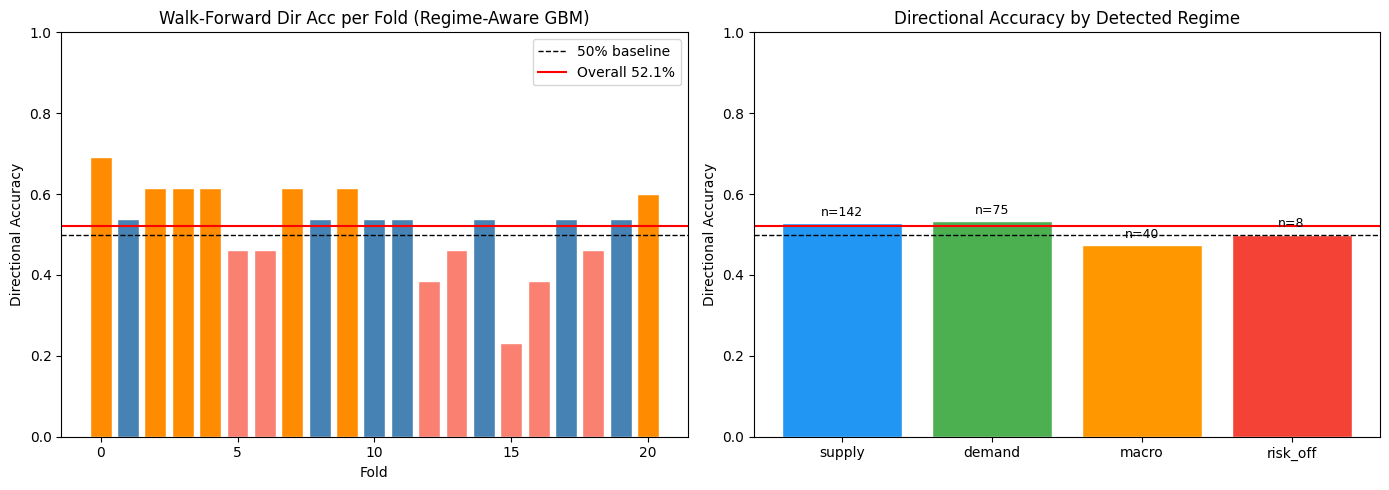


Top 15 features by permutation importance (last fold, OOS data):


inventory_surprise_kb_lag1    0.0573
opec_sentiment_lag1           0.0167
spx_ret_pct_lag1              0.0106
usd_ret_pct_lag1              0.0105
yield_10y_chg_lag1            0.0101
finbert_negative_mean_lag1    0.0063
disruption_cs_di_lag1         0.0047
usd_mom_4w_lag1               0.0042
sentiment_mean_lag1           0.0031
headline_count_lag1           0.0027
production_chg_kbd_lag1       0.0025
imports_chg_kbd_lag1          0.0024
positive_ratio_lag1           0.0020
inventory_chg_kb_lag1         0.0017
finbert_positive_mean_lag1    0.0014


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-fold dir acc bar chart
colors_bar = ['darkorange' if d >= 0.55 else 'steelblue' if d >= 0.50 else 'salmon'
              for d in folds_df['dir_acc']]
axes[0].bar(folds_df['fold'], folds_df['dir_acc'], color=colors_bar, edgecolor='white')
axes[0].axhline(0.50, color='black', linewidth=1, linestyle='--', label='50% baseline')
axes[0].axhline(dir_all, color='red', linewidth=1.5, label=f'Overall {dir_all:.1%}')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('Directional Accuracy')
axes[0].set_title('Walk-Forward Dir Acc per Fold (Regime-Aware GBM)')
axes[0].set_ylim(0, 1); axes[0].legend()

# Right: per-regime dir acc
regime_stats = []
for regime in ['supply', 'demand', 'macro', 'risk_off']:
    r = results[results['regime'] == regime]
    if len(r) < 3: continue
    da = np.mean(np.sign(r['pred'].values) == np.sign(r['actual'].values))
    regime_stats.append({'regime': regime, 'dir_acc': da, 'n': len(r)})
rs = pd.DataFrame(regime_stats)

REGIME_COLORS = {'supply':'#2196F3','demand':'#4CAF50','macro':'#FF9800','risk_off':'#F44336'}
bars = axes[1].bar(rs['regime'], rs['dir_acc'],
                   color=[REGIME_COLORS[r] for r in rs['regime']], edgecolor='white')
axes[1].axhline(0.50, color='black', linewidth=1, linestyle='--')
axes[1].axhline(dir_all, color='red', linewidth=1.5, linestyle='-')
for bar, row in zip(bars, rs.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'n={row.n}', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Directional Accuracy'); axes[1].set_ylim(0, 1)
axes[1].set_title('Directional Accuracy by Detected Regime')

plt.tight_layout(); plt.show()

# Feature importance on last fold
FEATURE_NAMES = BASE_FEATURE_COLS + REGIME_PROB_COLS
print('\nTop 15 features by permutation importance (last fold, OOS data):')
X_oos_full = np.hstack([
    X_base[INITIAL_TRAIN_WEEKS:INITIAL_TRAIN_WEEKS+len(results)],
    last_detector.predict_proba(df.iloc[INITIAL_TRAIN_WEEKS:INITIAL_TRAIN_WEEKS+len(results)]).values.astype(np.float32)
])
y_oos = y[INITIAL_TRAIN_WEEKS:INITIAL_TRAIN_WEEKS+len(results)]
X_oos_full, y_oos = X_oos_full[:len(results)], y_oos[:len(results)]

perm = permutation_importance(last_model, X_oos_full, y_oos, n_repeats=15,
                               random_state=42, scoring='neg_mean_absolute_error')
imp = pd.Series(perm.importances_mean, index=FEATURE_NAMES).sort_values(ascending=False)
print(imp.head(15).round(4).to_string())


## 6. Strategy Comparison

Walk-Forward Strategy Summary  (2021-02-12 → 2026-03-06)
High-confidence regimes: set()

            Strategy   Trades    Long   Short   Dir Acc     Final
----------------------------------------------------------------------
      Filtered (≥1%)       70      57      13     57.1%     0.944x

Buy & Hold: 1.415x
Naive:      1.411x


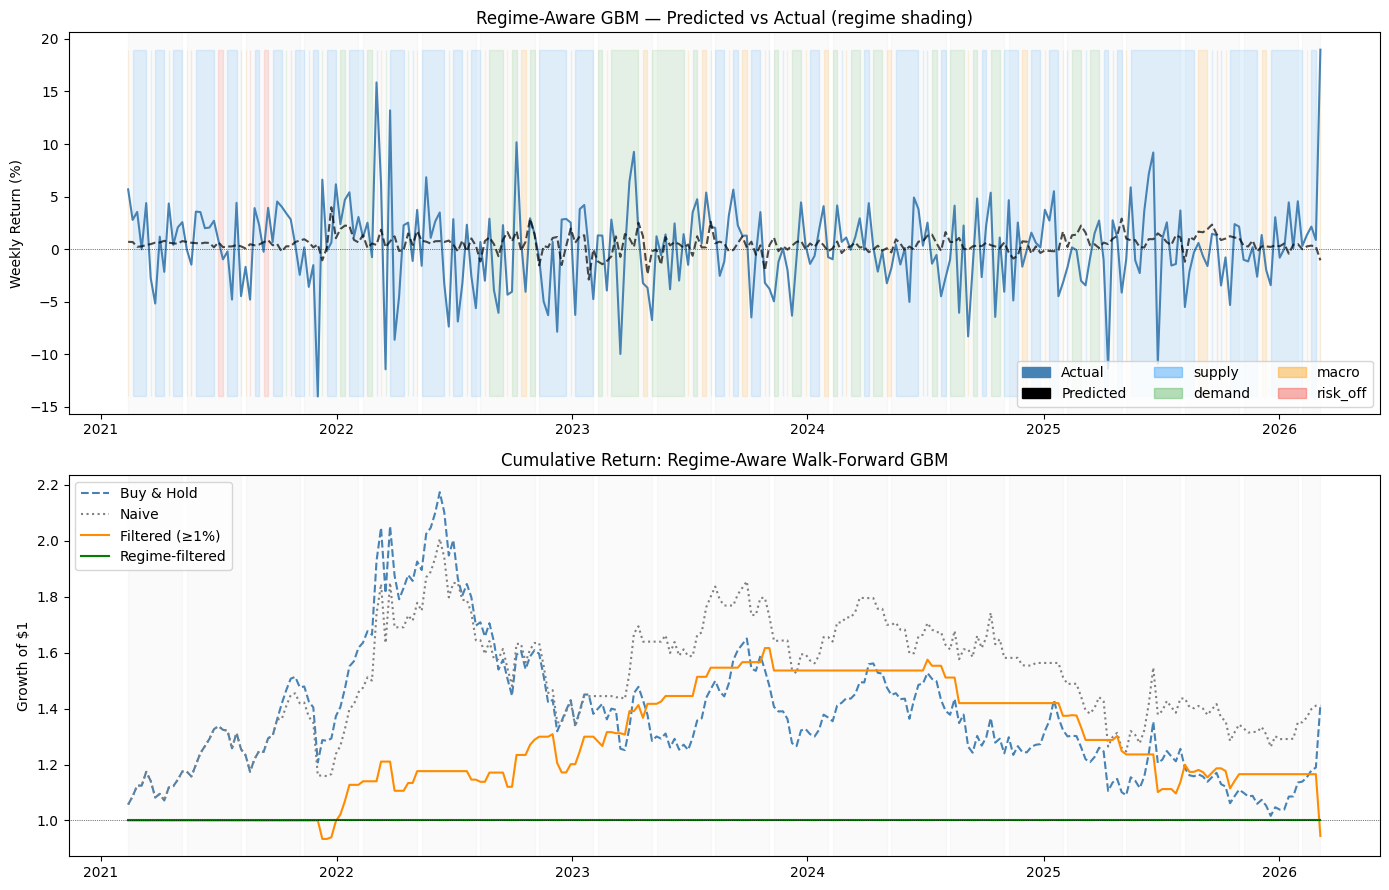

In [8]:
test_df = results.copy().sort_values('date').reset_index(drop=True)

test_df['signal_naive']    = np.where(test_df['pred'] > 0, 1, 0)
test_df['signal_filtered'] = np.where(
    test_df['pred'] >=  CONFIDENCE_THRESHOLD,  1,
    np.where(test_df['pred'] <= -CONFIDENCE_THRESHOLD, -1, 0))

test_df['return_naive']    = test_df['signal_naive']    * test_df['actual']
test_df['return_filtered'] = test_df['signal_filtered'] * test_df['actual']

test_df['cum_buyhold']  = (1 + test_df['actual']          / 100).cumprod()
test_df['cum_naive']    = (1 + test_df['return_naive']    / 100).cumprod()
test_df['cum_filtered'] = (1 + test_df['return_filtered'] / 100).cumprod()

# Per-regime strategy: only trade in regimes with dir_acc > 55%
high_conf_regimes = {r for r in rs['regime'] if rs.loc[rs['regime']==r,'dir_acc'].values[0] > 0.55}
test_df['signal_regime'] = np.where(
    test_df['regime'].isin(high_conf_regimes) & (test_df['pred'] >=  CONFIDENCE_THRESHOLD),  1,
    np.where(
    test_df['regime'].isin(high_conf_regimes) & (test_df['pred'] <= -CONFIDENCE_THRESHOLD), -1, 0))
test_df['return_regime'] = test_df['signal_regime'] * test_df['actual']
test_df['cum_regime']    = (1 + test_df['return_regime'] / 100).cumprod()

filt_mask  = test_df['signal_filtered'] != 0
regime_mask = test_df['signal_regime'] != 0

print(f'Walk-Forward Strategy Summary  ({test_df["date"].min().date()} → {test_df["date"].max().date()})')
print(f'High-confidence regimes: {high_conf_regimes}')
print()
print(f'{"Strategy":>20}  {"Trades":>7}  {"Long":>6}  {"Short":>6}  {"Dir Acc":>8}  {"Final":>8}')
print('-' * 70)
for label, mask, pred_col in [
    ('Filtered (≥1%)',   filt_mask,   'pred'),
    ('Regime-filtered',  regime_mask, 'pred'),
]:
    if mask.any():
        n_t = mask.sum()
        n_l = (test_df.loc[mask,'signal_filtered'] == 1).sum() if label=='Filtered (≥1%)' else (test_df.loc[mask,'signal_regime'] == 1).sum()
        n_s = n_t - n_l
        da  = np.mean(np.sign(test_df.loc[mask, pred_col]) == np.sign(test_df.loc[mask, 'actual']))
        fin = test_df['cum_filtered'].iloc[-1] if label=='Filtered (≥1%)' else test_df['cum_regime'].iloc[-1]
        print(f'{label:>20}  {n_t:>7}  {n_l:>6}  {n_s:>6}  {da:>8.1%}  {fin:>8.3f}x')

print()
print(f'Buy & Hold: {test_df["cum_buyhold"].iloc[-1]:.3f}x')
print(f'Naive:      {test_df["cum_naive"].iloc[-1]:.3f}x')

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for _, row in folds_df.iterrows():
    for ax in axes:
        ax.axvspan(pd.Timestamp(row['test_start']), pd.Timestamp(row['test_end']),
                   alpha=0.04, color='grey')

# Top: regime-shaded predicted vs actual
for regime, color in REGIME_COLORS.items():
    mask = test_df['regime'] == regime
    axes[0].fill_between(test_df['date'], test_df['actual'].min(), test_df['actual'].max(),
                         where=mask, alpha=0.12, color=color)
axes[0].plot(test_df['date'], test_df['actual'], label='Actual',    color='steelblue')
axes[0].plot(test_df['date'], test_df['pred'],   label='Predicted', color='black', linestyle='--', alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle=':')
regime_patches = [mpatches.Patch(color=c, alpha=0.4, label=r) for r, c in REGIME_COLORS.items()]
axes[0].legend(handles=[mpatches.Patch(color='steelblue', label='Actual'),
                          mpatches.Patch(color='black', label='Predicted')] + regime_patches, ncol=3)
axes[0].set_title('Regime-Aware GBM — Predicted vs Actual (regime shading)')
axes[0].set_ylabel('Weekly Return (%)')

axes[1].plot(test_df['date'], test_df['cum_buyhold'],  label='Buy & Hold',          color='steelblue', linestyle='--')
axes[1].plot(test_df['date'], test_df['cum_naive'],    label='Naive',               color='grey',      linestyle=':')
axes[1].plot(test_df['date'], test_df['cum_filtered'], label='Filtered (≥1%)',      color='darkorange')
axes[1].plot(test_df['date'], test_df['cum_regime'],   label='Regime-filtered',     color='green')
axes[1].axhline(1, color='black', linewidth=0.5, linestyle=':')
axes[1].set_title('Cumulative Return: Regime-Aware Walk-Forward GBM')
axes[1].set_ylabel('Growth of $1')
axes[1].legend()

plt.tight_layout()
plt.show()
